# 

### Задание 1
Опишите задачу с точки зрения NLP. Что это за задача, какие классические методы существуют для ее решения? Как ее можно решать через LLM? Как обычно оценивают качество моделей в этой задаче?

Выделения сущностей это классическая задача в сфере NLP. Обычно решается она с помощью BERT (Bidirectional Encoder Representations from Transformers) подобных моделей
- Закидываем текст в bert
- Берем эмбединги каждого токена
    - Из-за того, что классический bert имел токенизацию через WordPiece токены == слова
- Решаем задачу классификации на основе эмбедингов токенов

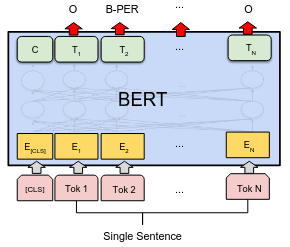

Решить её можно при помощи LLM путем промт инжиниринга. Эта задача - мультиклассовая классификация, поэтому метрики соответствующие:
- Balanced Accuracy
- Preccision
- Recal
- F1

### Задание 2
Реализуйте чтение датасета в pandas DataFrame с обязательными колонками "document_id", "document_text", "entity", "gold_answer". Выведите шапку датафрейма.

In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
TARGET_ENTITIES = ["PER", "ORG", "LOC", "EVT", "PRO"]


data = {"document_id": [], "document_text": []}#, "entity": [], "gold_answer": []}
for i in [53, 54, 55, 56, 57, 58, 59, 61, 62]:
    name = f"brexit_ru.txt_file_11{i}.txt"
    f = open(name)
    file = f.readlines()
    id = file[0].strip("\n").strip(" ")
    data["document_id"].append(id)
    data["document_text"].append("\n".join(file[6:]).strip("\n").strip())
    f.close()

In [63]:
data = pd.DataFrame(data)

entities = pd.DataFrame({"entity": [], "category": [], "document_id": []})
for i in [53, 54, 55, 56, 57, 58, 59, 61, 62]:
    f = open(f"brexit_ru.txt_file_11{i}.out")
    id = f.readline().strip("\n")
    tmp = pd.read_csv(f, header=None, sep="\t", names=["entity", "base-form", "category", "cross-lingual ID"]).drop(columns=["base-form", "cross-lingual ID"])
    tmp["document_id"] = id
    entities = pd.concat([entities, tmp])
entities = entities.join(data.set_index("document_id"), on="document_id")
entities

,entity,category,document_id,document_text
0,Борис Джонсон,PER,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
1,Великобритании,LOC,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
2,Великобритания,LOC,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
3,Дэвид Дэвис,PER,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
4,ЕС,ORG,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
...,...,...,...,...
30,Юлии,PER,ru-1162,В интервью телеканалу Sky News Джереми Хант по...
31,Юлия,PER,ru-1162,В интервью телеканалу Sky News Джереми Хант по...
32,британского,LOC,ru-1162,В интервью телеканалу Sky News Джереми Хант по...
33,британской,LOC,ru-1162,В интервью телеканалу Sky News Джереми Хант по...


array(['ru-1153', 'ru-1154', 'ru-1155', 'ru-1156', 'ru-1157', 'ru-1158',
       'ru-1159', 'ru-1161', 'ru-1162'], dtype=object)

### Задание 3
Напишите функцию, которая принимает на вход строку датафрейма и выдает текст входного сообщения для LLM.

In [67]:
def get_messages_for_llm(df: pd.DataFrame) -> list:
    texts = entities["document_text"].unique().tolist()

    for i in range(len(texts)):
        texts[i] = f"""Выдели сущности: {' '.join(TARGET_ENTITIES)}\n\nИз следующего текста: {texts[i]}"""
    return texts

In [68]:
entities

,entity,category,document_id,document_text
0,Борис Джонсон,PER,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
1,Великобритании,LOC,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
2,Великобритания,LOC,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
3,Дэвид Дэвис,PER,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
4,ЕС,ORG,ru-1153,Премьер-министр Великобритании Тереза Мэй наме...
...,...,...,...,...
30,Юлии,PER,ru-1162,В интервью телеканалу Sky News Джереми Хант по...
31,Юлия,PER,ru-1162,В интервью телеканалу Sky News Джереми Хант по...
32,британского,LOC,ru-1162,В интервью телеканалу Sky News Джереми Хант по...
33,британской,LOC,ru-1162,В интервью телеканалу Sky News Джереми Хант по...


In [72]:
for i in get_messages_for_llm(entities):
    print(i)
    print("-------")

Выдели сущности: PER ORG LOC EVT PRO

Из следующего текста: Премьер-министр Великобритании Тереза Мэй намерена заключить с ЕС соглашение, которое будет максимально выгодно для жителей Соединенного Королевства. В этом глава правительства заверила накануне британский парламент. Мы предложим Европейскому союзу пересмотреть свои позиции, и подписать новое соглашение о правах и обязанностях каждой стороны. Только так можно добиться сохранения конституционной целостности и выполнения целей, обозначенных на референдуме, - сказала премьер-министр Великобритании Тереза Мэй. Тереза Мэй сообщила, что новая стратегия на переговорах по брекситу будет опубликована 14 июля. После ее утверждения в кабмине свои посты покинули министр иностранных дел Борис Джонсон и министр по вопросам брексита Дэвид Дэвис. Оба - сторонники жестких подходов к выходу из ЕС. Они раскритиковали новую стратегию за мягкость и заявили что мечта о брексите умирает.
-------
Выдели сущности: PER ORG LOC EVT PRO

Из следующего те

### Задание 4
Получите ответы GigaChat для всех документов. Документов всего 9, поэтому сделать это можно вручную, пользуясь веб-интерфейсом GigaChat или ботом в ВК или Телеграме. Не очищайте историю сообщений, чтобы потом продемонстрировать подлинность ответов на онлайн-собеседовании.
Внесите ответы GigaChat в датафрейм, сохраните его.

In [262]:
predictions = [{"PER_Тереза Мэй", "PER_Борис Джонсон", "PER_Дэвид Дэвис",
                "ORG_ЕС", "ORG_британский парламент", "ORG_кабинет министров",
                "LOC_Великобритания", "LOC_Соединенное Королевство", 
                "EVT_заключение соглашения", "EVT_переговоры по брекситу", "EVT_референдум",
                "PRO_соглашение", "PRO_права и обязанности", "PRO_новая стратегия"},
                {"PER_None", "ORG_None", "LOC_None", "EVT_None", "PRO_None"}, # GigaChat отказался предсказывать, даже после длительных эксперементов с промтом
                {'PER_Джереми Хант', "PER_Мэттью Хэнкок", "PER_Джереми Райт", "PER_Дэвид Кэмерон", "PER_Т.Мэй", "PER_Б.Джонсон", 
                 "PER_Дэвид Дэвис",
                 "ORG_Консервативная партия", "ORG_Министерство иностранных дел Великобритании", "ORG_Правительство Британии", 
                 "ORG_Кабинет министров Великобритании", "ORG_Генеральный прокурор Англии и Уэльса",
                 "LOC_Великобритания", "LOC_Англия", "LOC_Уэльс", "LOC_ЕС",
                 "EVT_Референдум о выходе Британии из ЕС", "EVT_Отставка Бориса Джонсона", "EVT_Назначение Джереми Ханта министром иностранных дел",
                 "EVT_Переговоры с ЕС по выходу из союза",
                 "PRO_Министр иностранных дел", "PRO_Министр здравоохранения", "PRO_Министр по цифровым технологиям, культуре, СМИ и спорту",
                 "PRO_Министр культуры", "PRO_СМИ", "PRO_Олимпийских игр и спорта", "PRO_Министр по делам Brexit"},
                 {"PER_None", "ORG_None", "LOC_None", "EVT_None", "PRO_None"}, # GigaChat отказался предсказывать, даже после длительных эксперементов с промтом
                 {"PER_Джереми Хант", "PER_Борис Джонсон", "PER_Тереза Мэй", "ORG_Министерство иностранных дел Великобритании", 
                  "ORG_Минздрав Великобритании", "ORG_Профильное министерство", "PER_Кабинет министров Великобритании", "PER_МИД Великобритании",
                  "LOC_Великобритания", "LOC_Россия",
                  "EVT_Назначение Джереми Ханта министром иностранных дел", "EVT_Отставка Бориса Джонсона", "EVT_Возможный правительственный кризис", 
                  "EVT_Матч полуфинала чемпионата мира по футболу в России",
                  "PRO_Министр иностранных дел", "PRO_Глава МИД", "PRO_Премьер-министр", "PRO_Глава профильного министерства", "PRO_Министр здравоохранения",
                  "PRO_Министр цифровых технологий, культуры, СМИ и спорта"},
                  {"PER_None", "ORG_None", "LOC_None", "EVT_None", "PRO_None"}, # GigaChat отказался предсказывать, даже после длительных эксперементов с промтом
                  {"PER_None", "ORG_None", "LOC_None", "EVT_None", "PRO_None"}, # GigaChat отказался предсказывать, даже после длительных эксперементов с промтом
                  {"PER_Борис Джонсон", "PER_Тереза Мэй", "ORG_правительство", "ORG_парламент", "ORG_Евросоюз", "ORG_BBC", "ORG_ONLINE.UA",
                   "LOC_Великобритания", "LOC_ЕС", "EVT_отставка Бориса Джонсона", "EVT_Brexit", "PRO_обязательства"},
                  {"PER_None", "ORG_None", "LOC_None", "EVT_None", "PRO_None"} # GigaChat отказался предсказывать, даже после длительных эксперементов с промтом
                 ]

In [263]:
# Сохранение результатов предсказаний
pred_dct = {"entity": [], "category": [], "document_id": []}
for i in range(9):
    ids = entities["document_id"].unique()
    for row in predictions[i]:
        pred_dct['document_id'].append(ids[i])
        a, b = row.split("_")
        pred_dct["category"].append(a)
        pred_dct["entity"].append(b)
pred_csv = pd.DataFrame(pred_dct)
pred_csv.to_csv("res.csv", index=None)
pred_csv

,entity,category,document_id
0,Великобритания,LOC,ru-1153
1,новая стратегия,PRO,ru-1153
2,Дэвид Дэвис,PER,ru-1153
3,переговоры по брекситу,EVT,ru-1153
4,ЕС,ORG,ru-1153
...,...,...,...
93,None,EVT,ru-1162
94,None,LOC,ru-1162
95,None,PER,ru-1162
96,None,PRO,ru-1162


### Задание 5

Реализуйте самостоятельно алгоритм для подсчета метрик score_fn(gold: str, pred: str) → float. Можно пользоваться только библиотеками numpy, scipy, pandas. Напишите юнит-тесты. Возможно ли ускорить вычисление функции через векторную реализацию? Поясните решение и обоснуйте, почему выбрали именно такую метрику.

Я немного переработал функцию, которая должна была считать скор, т.к. в идеале исходная работала бы при условии что GigaChat выдаст предсказания для каждого слова (токена). Но теперь функция выгляит более элегантно. Ускорить через векторную реализацию нельзя т.к. нам не дан размеченный ряд. Вместо этого ускорил через хеш.
Выбрал f1 т.к. его тяжелее всего реализовать

$$

F_1 = 2\frac{Precision * Recall}{Precision + Recall} = 2\frac{TP}{2TP +FN + FP}
$$

In [299]:
from collections import defaultdict

dct = {id: defaultdict(set) for id in entities["document_id"].unique()} # Переменная для хранения хеша правильных ответов
dct = defaultdict(lambda: defaultdict(lambda: "other"))
for i, row in entities.iterrows():
    dct[row["document_id"]][row["entity"]] = row["category"]

In [318]:
def score_fn(TP, FN, FP): # Сложность O(1), немного отошел от условия, чтобы больше погрузиться в задачу
    if TP + FN + FP == 0:
        return 0
    return 2 * (TP) / (2 * TP + FN + FP)

In [319]:
assert score_fn(0, 0, 0) == 0
assert score_fn(1, 1, 1) == 0.5

### Задание 6
Вычислите метрики для каждой строки в датафрейме. Сагрегируйте результаты а) по каждой сущности, б) по каждому документу. Изобразите результаты на графиках. Какие выводы можно сделать?

In [320]:
# Считаем TP для всех предсказаний
score_table = pred_csv.copy()
for target in TARGET_ENTITIES + ["other"]:
    score_table[f"TP_{target}"] = 0
    score_table[f"FP_{target}"] = 0
    score_table[f"FN_{target}"] = 0
for i, row in score_table.iterrows():
    if row["category"] == dct[row["document_id"]][row["entity"]]:
        score_table.loc[i, f'TP_{row["category"]}'] += 1
    else:
        score_table.loc[i, f'FP_{row["category"]}'] += 1
        score_table.loc[i, f'FN_{dct[row["document_id"]][row["entity"]]}'] += 1
#score_table["TP"] = score_table.apply(lambda row: int((row["entity"], row["category"], row["document_id"]) in dct), axis=1)
score_table

,entity,category,document_id,TP_PER,FP_PER,FN_PER,TP_ORG,FP_ORG,FN_ORG,TP_LOC,...,FN_LOC,TP_EVT,FP_EVT,FN_EVT,TP_PRO,FP_PRO,FN_PRO,TP_other,FP_other,FN_other
0,Великобритания,LOC,ru-1153,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,новая стратегия,PRO,ru-1153,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,Дэвид Дэвис,PER,ru-1153,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,переговоры по брекситу,EVT,ru-1153,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,ЕС,ORG,ru-1153,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,None,EVT,ru-1162,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
94,None,LOC,ru-1162,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
95,None,PER,ru-1162,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
96,None,PRO,ru-1162,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [356]:
print("Агрегация по категориям:")
tmp = pd.DataFrame({"category": TARGET_ENTITIES, "f1": [score_fn(score_table[f"TP_{target}"].sum(), score_table[f"FN_{target}"].sum(), score_table[f"FP_{target}"].sum()) for target in TARGET_ENTITIES]})
tmp

Агрегация по категориям:


,category,f1
0,PER,0.705882
1,ORG,0.160000
2,LOC,0.235294
3,EVT,0.105263
4,PRO,0.000000


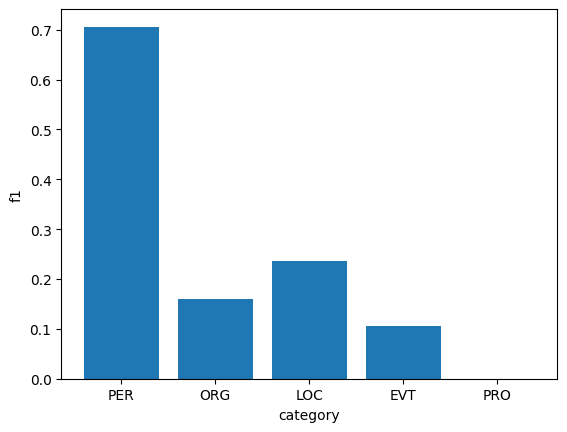

In [357]:
plt.bar(tmp["category"], tmp["f1"])
plt.xlabel('category')
plt.ylabel('f1');

In [358]:
print("Агрегация по документам:")
tmp = score_table.groupby('document_id').apply(
    lambda x: sum([score_fn(x[f"TP_{target}"].sum(), x[f"FN_{target}"].sum(), x[f"FP_{target}"].sum()) for target in TARGET_ENTITIES]) / len(TARGET_ENTITIES),
).reset_index()
tmp = tmp.rename(columns={0: "macro-f1"})
tmp

Агрегация по документам:


/tmp/ipykernel_63456/796240451.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = score_table.groupby('document_id').apply(


,document_id,macro-f1
0,ru-1153,0.493333
1,ru-1154,0.000000
2,ru-1155,0.184615
3,ru-1156,0.000000
4,ru-1157,0.066667
5,ru-1158,0.000000
6,ru-1159,0.000000
7,ru-1161,0.466667
8,ru-1162,0.000000


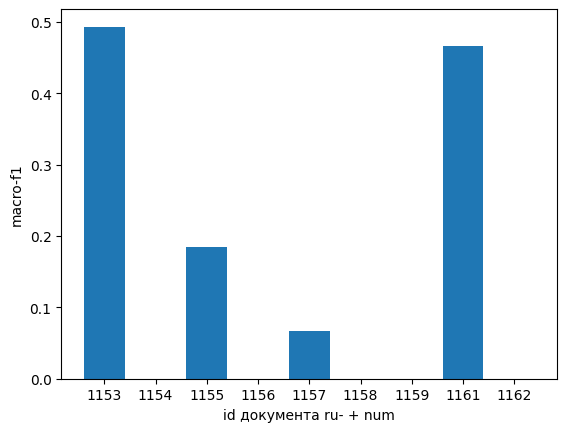

In [359]:
# На непредставленные GigaChat отказался предсказывать, даже после длительных эксперементов с промтом
plt.bar(tmp["document_id"].apply(lambda x: x[3:]), tmp["macro-f1"])
plt.xlabel('id документа ru- + num')
plt.ylabel('macro-f1');

### Задание 7
Есть ли зависимость метрик от длины документа? Постройте графики, чтобы ответить на вопрос.

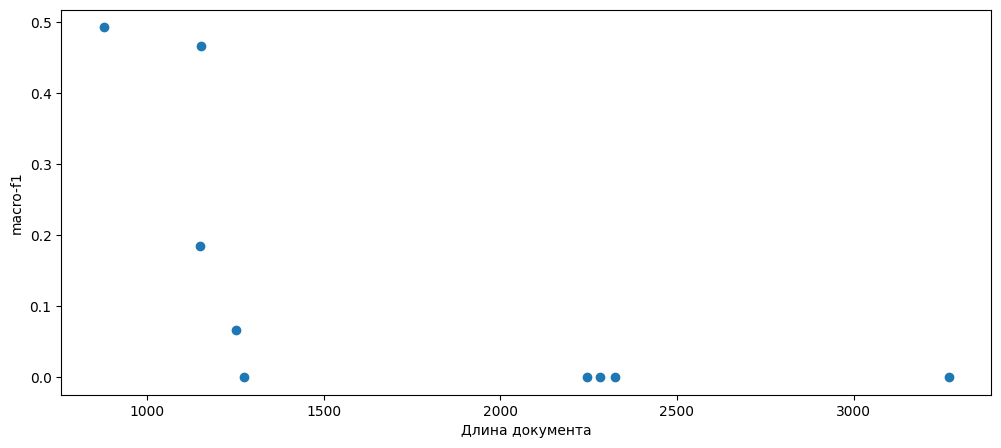

In [360]:
plt.figure(figsize=(12, 5))
plt.scatter(pd.Series(entities["document_text"].unique()).apply(len), tmp["macro-f1"])
plt.xlabel('Длина документа')
plt.ylabel('macro-f1');

Зависимость присутствует, чем меньше текст по размеру, тем точнее LLM выделяет сущности

### Задание 8
Проведите анализ ошибок. Когда модель чаще отвечает правильно, а когда ошибается? Предложите варианты, как повысить метрики.

Я думаю, что идея и чем-то похожа на BAAI/bge-multilingual-gemma2, где они используют LLM для ранжирования. Модель доступная для обывателей супер защищена и при некоторых текстах я так и не смог получить сущности, сколько бы я не эксперементировал с промтом. Если бы передо мной стояла задача выжать максимум из LLM для NER задачи, я бы протестировал следующие идеи
- Прогон через LLM исходного текста с целью составить краткий пересказ с опорой на основные события и имена
- Затюнил бы LLM, чтобы отредактировать формат вывода 
    - LLM лучше будет следовать иснтрукциям
    - Поймет суть задачи
- Отслеживание по ключевым словам NER задачи
    - Мне показалось что GigaChat затюнен под эту задачу, если это так я думаю можно убрать защиту  на этой задаче
        - LLM не выдаёт собственого мнения а лишь следует иструкциям по тюненной задаче 
    - Если возможно воткнул бы bert-подобную архитектуру

### Задание 9
Сделайте выводы по всему исследованию. Напишите, чему научились и что нового попробовали.

##### Выводы
Открытая модель GigaChat хорошо справляеться с задачей выделения сущностей на маленьком объеме текста. Однако с увеличением объема текста LLM начинает анализировать текст.
##### Чему я научился
Открыл для себя что $\sum_i FP_i = \sum_i FN_i$ по всем класам. Протестировал идею использоваyния LLM в NER. Помимо текущей задачи заинтересовался как решают NER классическим способом и как устроен BERT. Сделал мини конспект